# Advanced Ensemble Models - Final Implementation

This notebook implements Phase 2+ of model improvement strategy:
- **Phase 2**: Weighted and Non-Weighted Voting Ensembles
- **Phase 3**: Meta-Learning (Stacking) with diverse base models
- **Phase 4**: Hybrid Approaches (Blending, Meta-Boosting)

We'll use a diverse set of models:
- **Tree-based**: XGBoost, LightGBM, CatBoost, Random Forest, Decision Tree
- **Linear**: Logistic Regression, SVC
- **Instance-based**: KNN

## 1. Import Libraries and Load Data

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    VotingClassifier, 
    StackingClassifier,
    BaggingClassifier
)
from sklearn.naive_bayes import GaussianNB

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model evaluation
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    cross_validate,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Utilities
import joblib
from datetime import datetime

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load preprocessed data
df = pd.read_csv('/Users/ronakpanchal/Desktop/College/ML/lab/Project/datasets/heart_preprocessed_scaled.csv')

# Prepare features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")

Training set size: (734, 15)
Test set size: (184, 15)
Class distribution in training set:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64


## 2. Define Base Models

We'll use optimized hyperparameters from Phase 1 (cv_hyperparameter_tuned folder)

In [3]:
# Define all base models with optimized hyperparameters

# Tree-based boosting models
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_dart = XGBClassifier(
    booster='dart',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    rate_drop=0.1,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1
)

lgbm_dart = LGBMClassifier(
    boosting_type='dart',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1
)

catboost_model = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=0
)

catboost_lossguide = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.1,
    grow_policy='Lossguide',
    random_state=RANDOM_STATE,
    verbose=0
)

# Traditional tree models
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)

dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=RANDOM_STATE
)

# Linear models
logreg_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

ridge_model = RidgeClassifier(
    alpha=1.0,
    random_state=RANDOM_STATE
)

svc_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    probability=True,  # Important for soft voting
    random_state=RANDOM_STATE
)

# Instance-based model
knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski'
)

# Naive Bayes (for diversity)
nb_model = GaussianNB()

print("All base models defined successfully!")

All base models defined successfully!


## 3. Helper Functions for Evaluation

In [4]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Train and evaluate a model, returning comprehensive metrics
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    }
    
    return metrics, model

def evaluate_with_cv(model, X, y, model_name="Model", cv=5):
    """
    Evaluate model using cross-validation
    """
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    
    cv_results = cross_validate(
        model, X, y, 
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    metrics = {
        'Model': model_name,
        'CV_Accuracy': cv_results['test_accuracy'].mean(),
        'CV_Precision': cv_results['test_precision'].mean(),
        'CV_Recall': cv_results['test_recall'].mean(),
        'CV_F1': cv_results['test_f1'].mean(),
        'CV_ROC_AUC': cv_results['test_roc_auc'].mean(),
        'Std_Accuracy': cv_results['test_accuracy'].std()
    }
    
    return metrics

def compare_models(results_df, baseline_accuracy=0.897):
    """
    Compare models and highlight improvements over baseline
    """
    results_df = results_df.sort_values('Accuracy', ascending=False)
    results_df['Improvement'] = ((results_df['Accuracy'] - baseline_accuracy) * 100).round(2)
    
    return results_df

def plot_model_comparison(results_df, metric='Accuracy', title='Model Comparison'):
    """
    Visualize model performance comparison
    """
    plt.figure(figsize=(12, 6))
    
    # Sort by metric
    results_sorted = results_df.sort_values(metric, ascending=True)
    
    # Create horizontal bar plot
    colors = ['green' if x > 0.89 else 'orange' if x > 0.87 else 'red' 
              for x in results_sorted[metric]]
    
    plt.barh(results_sorted['Model'], results_sorted[metric], color=colors, alpha=0.7)
    plt.xlabel(metric, fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axvline(x=0.897, color='red', linestyle='--', label='Baseline (Random Forest: 89.7%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

print("Helper functions defined successfully!")

Helper functions defined successfully!


## 4. Phase 2.1: Simple Voting Ensembles

### 4.1 Hard Voting (Majority Vote)

In [5]:
# Hard Voting Classifier - All Models
hard_voting_all = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('dt', dt_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    voting='hard',
    n_jobs=-1
)
hard_voting_all_score = cross_val_score(hard_voting_all, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Hard Voting (All Models) CV ROC-AUC Scores: {hard_voting_all_score.mean()}")
# Train and evaluate
metrics_hard_all, trained_hard_all = evaluate_model(
    hard_voting_all, X_train, X_test, y_train, y_test, 
    "Hard Voting (All Models)"
)

Hard Voting (All Models) CV ROC-AUC Scores: nan


In [6]:
print(metrics_hard_all)

{'Model': 'Hard Voting (All Models)', 'Accuracy': 0.907608695652174, 'Precision': 0.9207920792079208, 'Recall': 0.9117647058823529, 'F1': 0.916256157635468, 'ROC_AUC': None}


In [7]:
# Hard Voting - Top Performers Only (Tree-based)
hard_voting_top = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model)
    ],
    voting='hard',
    n_jobs=-1
)

metrics_hard_top, trained_hard_top = evaluate_model(
    hard_voting_top, X_train, X_test, y_train, y_test, 
    "Hard Voting (Top 4 Tree Models)"
)

# print("\nHard Voting (Top 4 Tree Models) Results:")
# for key, value in metrics_hard_top.items():
#     if key != 'Model':
#         print(f"{key}: {value:.4f}")

In [8]:
print(metrics_hard_top)

{'Model': 'Hard Voting (Top 4 Tree Models)', 'Accuracy': 0.8913043478260869, 'Precision': 0.91, 'Recall': 0.8921568627450981, 'F1': 0.900990099009901, 'ROC_AUC': None}


In [9]:
# Hard Voting - Diverse Models (Tree + Linear + Instance)
hard_voting_diverse = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    voting='hard',
    n_jobs=-1
)

metrics_hard_diverse, trained_hard_diverse = evaluate_model(
    hard_voting_diverse, X_train, X_test, y_train, y_test, 
    "Hard Voting (Diverse Models)"
)

# print("\nHard Voting (Diverse Models) Results:")
# for key, value in metrics_hard_diverse.items():
#     if key != 'Model':
#         print(f"{key}: {value:.4f}")

In [10]:
print(metrics_hard_diverse)

{'Model': 'Hard Voting (Diverse Models)', 'Accuracy': 0.8967391304347826, 'Precision': 0.8952380952380953, 'Recall': 0.9215686274509803, 'F1': 0.9082125603864735, 'ROC_AUC': None}


### 4.2 Soft Voting (Probability Averaging)

In [6]:
# Soft Voting Classifier - All Models
soft_voting_all = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('dt', dt_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model),
        ('nb', nb_model)
    ],
    voting='soft',
    n_jobs=-1
)
soft_voting_all_score = cross_val_score(soft_voting_all, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Soft Voting (All Models) CV ROC-AUC Scores: {soft_voting_all_score.mean()}")
metrics_soft_all, trained_soft_all = evaluate_model(
    soft_voting_all, X_train, X_test, y_train, y_test, 
    "Soft Voting (All Models)"
)

print("Soft Voting (All Models) Results:")
for key, value in metrics_soft_all.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Soft Voting (All Models) CV ROC-AUC Scores: 0.9120469148780014
Soft Voting (All Models) Results:
Accuracy: 0.9022
Precision: 0.9118
Recall: 0.9118
F1: 0.9118
ROC_AUC: 0.9372


In [7]:
# Soft Voting - Boosting Models Only
soft_voting_boosting = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('xgb_dart', xgb_dart),
        ('lgbm', lgbm_model),
        ('lgbm_dart', lgbm_dart),
        ('catboost', catboost_model),
        ('catboost_lg', catboost_lossguide)
    ],
    voting='soft',
    n_jobs=-1
)
soft_voting_boosting_score = cross_val_score(soft_voting_boosting, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Soft Voting (Boosting Variants) CV ROC-AUC Scores: {soft_voting_boosting_score.mean()}")
metrics_soft_boosting, trained_soft_boosting = evaluate_model(
    soft_voting_boosting, X_train, X_test, y_train, y_test, 
    "Soft Voting (Boosting Variants)"
)

print("\nSoft Voting (Boosting Variants) Results:")
for key, value in metrics_soft_boosting.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Soft Voting (Boosting Variants) CV ROC-AUC Scores: 0.9013326798963972

Soft Voting (Boosting Variants) Results:
Accuracy: 0.8750
Precision: 0.8911
Recall: 0.8824
F1: 0.8867
ROC_AUC: 0.9275


In [8]:
# Soft Voting - Diverse Models
soft_voting_diverse = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    voting='soft',
    n_jobs=-1
)
soft_voting_diverse_score = cross_val_score(soft_voting_diverse, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Soft Voting (Diverse Models) CV ROC-AUC Scores: {soft_voting_diverse_score.mean()}")
metrics_soft_diverse, trained_soft_diverse = evaluate_model(
    soft_voting_diverse, X_train, X_test, y_train, y_test, 
    "Soft Voting (Diverse Models)"
)

print("\nSoft Voting (Diverse Models) Results:")
for key, value in metrics_soft_diverse.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Soft Voting (Diverse Models) CV ROC-AUC Scores: 0.9119396659895544

Soft Voting (Diverse Models) Results:
Accuracy: 0.8967
Precision: 0.9109
Recall: 0.9020
F1: 0.9064
ROC_AUC: 0.9384


## 5. Phase 2.2: Weighted Voting Ensembles

### 5.1 Performance-Based Weights

In [10]:
# Define weights based on baseline model performance (from model_metrics.csv)
# Higher performing models get more weight

baseline_performance = {
    'xgb': 0.8913,      # Best baseline
    'lgbm': 0.8859,
    'rf': 0.8750,
    'dt': 0.8859,
    'logreg': 0.8424,
    'svc': 0.8370,
    'knn': 0.8750
}

# Normalize weights to sum to 1
total_performance = sum(baseline_performance.values())
performance_weights = {k: v/total_performance for k, v in baseline_performance.items()}

print("Performance-based weights:")
for model, weight in performance_weights.items():
    print(f"{model}: {weight:.4f}")

Performance-based weights:
xgb: 0.1463
lgbm: 0.1454
rf: 0.1436
dt: 0.1454
logreg: 0.1383
svc: 0.1374
knn: 0.1436


In [11]:
# Weighted Soft Voting - Performance Based
weighted_voting_performance = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    voting='soft',
    weights=[
        performance_weights['xgb'],
        performance_weights['lgbm'],
        performance_weights['xgb'],  # Using xgb weight for catboost (similar performance)
        performance_weights['rf'],
        performance_weights['logreg'],
        performance_weights['svc'],
        performance_weights['knn']
    ],
    n_jobs=-1
)
weighted_voting_all_score = cross_val_score(weighted_voting_performance, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Weighted Voting (Performance-Based) CV ROC-AUC Scores: {weighted_voting_all_score.mean()}")
metrics_weighted_perf, trained_weighted_perf = evaluate_model(
    weighted_voting_performance, X_train, X_test, y_train, y_test, 
    "Weighted Voting (Performance-Based)"
)

print("\nWeighted Voting (Performance-Based) Results:")
for key, value in metrics_weighted_perf.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Weighted Voting (Performance-Based) CV ROC-AUC Scores: 0.9131565739070322

Weighted Voting (Performance-Based) Results:
Accuracy: 0.8913
Precision: 0.9020
Recall: 0.9020
F1: 0.9020
ROC_AUC: 0.9387


### 5.2 Inverse Error Weights

In [12]:
# Calculate inverse error weights
# Weight = 1 / (1 - accuracy)

inverse_error_weights = {}
for model, acc in baseline_performance.items():
    inverse_error_weights[model] = 1 / (1 - acc)

# Normalize
total_inv_error = sum(inverse_error_weights.values())
inverse_error_weights = {k: v/total_inv_error for k, v in inverse_error_weights.items()}

print("Inverse error weights:")
for model, weight in inverse_error_weights.items():
    print(f"{model}: {weight:.4f}")

Inverse error weights:
xgb: 0.1666
lgbm: 0.1587
rf: 0.1449
dt: 0.1587
logreg: 0.1149
svc: 0.1111
knn: 0.1449


In [13]:
# Weighted Soft Voting - Inverse Error Based
weighted_voting_inverse = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    voting='soft',
    weights=[
        inverse_error_weights['xgb'],
        inverse_error_weights['lgbm'],
        inverse_error_weights['xgb'],  # Using xgb weight for catboost
        inverse_error_weights['rf'],
        inverse_error_weights['logreg'],
        inverse_error_weights['svc'],
        inverse_error_weights['knn']
    ],
    n_jobs=-1
)
weighted_voting_inverse_score = cross_val_score(weighted_voting_inverse, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Weighted Voting (Inverse Error) CV ROC-AUC Scores: {weighted_voting_inverse_score.mean()}")
metrics_weighted_inv, trained_weighted_inv = evaluate_model(
    weighted_voting_inverse, X_train, X_test, y_train, y_test, 
    "Weighted Voting (Inverse Error)"
)

print("\nWeighted Voting (Inverse Error) Results:")
for key, value in metrics_weighted_inv.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Weighted Voting (Inverse Error) CV ROC-AUC Scores: 0.9127240270655472

Weighted Voting (Inverse Error) Results:
Accuracy: 0.8967
Precision: 0.9109
Recall: 0.9020
F1: 0.9064
ROC_AUC: 0.9383


### 5.3 Custom Optimized Weights

In [15]:
# Custom weights - emphasizing boosting models
# Based on model diversity and reliability

custom_weights = [2.5, 2.0, 2.5, 1.5, 0.8, 0.7, 1.0]  # Favors XGBoost, CatBoost, LightGBM

weighted_voting_custom = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    voting='soft',
    weights=custom_weights,
    n_jobs=-1
)
weighted_voting_custom_score = cross_val_score(weighted_voting_custom, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Weighted Voting (Custom Optimized) CV ROC-AUC Scores: {weighted_voting_custom_score.mean()}")
metrics_weighted_custom, trained_weighted_custom = evaluate_model(
    weighted_voting_custom, X_train, X_test, y_train, y_test, 
    "Weighted Voting (Custom Optimized)"
)

print("\nWeighted Voting (Custom Optimized) Results:")
for key, value in metrics_weighted_custom.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Weighted Voting (Custom Optimized) CV ROC-AUC Scores: 0.9108688343726768

Weighted Voting (Custom Optimized) Results:
Accuracy: 0.8967
Precision: 0.9109
Recall: 0.9020
F1: 0.9064
ROC_AUC: 0.9365


## 6. Phase 3: Stacking Ensembles (Meta-Learning)

### 6.1 Two-Level Stacking with Logistic Regression Meta-Learner

In [16]:
# Stacking Classifier - Logistic Regression as meta-learner
stacking_logreg = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('dt', dt_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)
stacking_logreg_score = cross_val_score(stacking_logreg, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Stacking (LogReg Meta-Learner) CV ROC-AUC Scores: {stacking_logreg_score.mean()}")
metrics_stack_logreg, trained_stack_logreg = evaluate_model(
    stacking_logreg, X_train, X_test, y_train, y_test, 
    "Stacking (LogReg Meta-Learner)"
)

print("Stacking (LogReg Meta-Learner) Results:")
for key, value in metrics_stack_logreg.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Stacking (LogReg Meta-Learner) CV ROC-AUC Scores: 0.9110295893290907
Stacking (LogReg Meta-Learner) Results:
Accuracy: 0.9022
Precision: 0.9038
Recall: 0.9216
F1: 0.9126
ROC_AUC: 0.9390


### 6.2 Two-Level Stacking with LightGBM Meta-Learner

In [17]:
# Stacking Classifier - LightGBM as meta-learner
stacking_lgbm = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('dt', dt_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    final_estimator=LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1),
    cv=5,
    n_jobs=-1
)
stacking_lgbm_score = cross_val_score(stacking_lgbm, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Stacking (LGBM Meta-Learner) CV ROC-AUC Scores: {stacking_lgbm_score.mean()}")
metrics_stack_lgbm, trained_stack_lgbm = evaluate_model(
    stacking_lgbm, X_train, X_test, y_train, y_test, 
    "Stacking (LGBM Meta-Learner)"
)

print("\nStacking (LGBM Meta-Learner) Results:")
for key, value in metrics_stack_lgbm.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Stacking (LGBM Meta-Learner) CV ROC-AUC Scores: 0.8892540401816363

Stacking (LGBM Meta-Learner) Results:
Accuracy: 0.8804
Precision: 0.8704
Recall: 0.9216
F1: 0.8952
ROC_AUC: 0.9193


### 6.3 Two-Level Stacking with XGBoost Meta-Learner

In [18]:
# Stacking Classifier - XGBoost as meta-learner (Meta-Boosting)
stacking_xgb = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('dt', dt_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    final_estimator=XGBClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_STATE, eval_metric='logloss'),
    cv=5,
    n_jobs=-1
)
stacking_xgb_score = cross_val_score(stacking_xgb, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Stacking (XGB Meta-Learner) CV ROC-AUC Scores: {stacking_xgb_score.mean()}")
metrics_stack_xgb, trained_stack_xgb = evaluate_model(
    stacking_xgb, X_train, X_test, y_train, y_test, 
    "Stacking (XGB Meta-Learner)"
)

print("\nStacking (XGB Meta-Learner) Results:")
for key, value in metrics_stack_xgb.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Stacking (XGB Meta-Learner) CV ROC-AUC Scores: 0.8840393293274807

Stacking (XGB Meta-Learner) Results:
Accuracy: 0.8967
Precision: 0.8807
Recall: 0.9412
F1: 0.9100
ROC_AUC: 0.9242


### 6.4 Two-Level Stacking with Ridge Classifier Meta-Learner

In [22]:
# Stacking Classifier - Ridge as meta-learner
stacking_ridge = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    final_estimator=RidgeClassifier(alpha=1.0, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

metrics_stack_ridge, trained_stack_ridge = evaluate_model(
    stacking_ridge, X_train, X_test, y_train, y_test, 
    "Stacking (Ridge Meta-Learner)"
)

# print("\nStacking (Ridge Meta-Learner) Results:")
# for key, value in metrics_stack_ridge.items():
#     if key != 'Model':
#         print(f"{key}: {value:.4f}")

In [23]:
print(metrics_stack_ridge)

{'Model': 'Stacking (Ridge Meta-Learner)', 'Accuracy': 0.9021739130434783, 'Precision': 0.9038461538461539, 'Recall': 0.9215686274509803, 'F1': 0.912621359223301, 'ROC_AUC': None}


### 6.5 Stacking with Diverse Base Models Only

In [19]:
# Stacking with diverse models (better generalization)
stacking_diverse = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('catboost', catboost_model),
        ('rf', rf_model),
        ('logreg', logreg_model),
        ('svc', svc_model),
        ('knn', knn_model)
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)
stacking_diverse_score = cross_val_score(stacking_diverse, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"Stacking (Diverse Base Models) CV ROC-AUC Scores: {stacking_diverse_score.mean()}")
metrics_stack_diverse, trained_stack_diverse = evaluate_model(
    stacking_diverse, X_train, X_test, y_train, y_test, 
    "Stacking (Diverse Base Models)"
)

print("\nStacking (Diverse Base Models) Results:")
for key, value in metrics_stack_diverse.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Stacking (Diverse Base Models) CV ROC-AUC Scores: 0.9118613009077091

Stacking (Diverse Base Models) Results:
Accuracy: 0.9076
Precision: 0.9126
Recall: 0.9216
F1: 0.9171
ROC_AUC: 0.9402


### 6.6 Stacking with Boosting Models + Linear Meta-Learner

In [25]:
# Stacking with only boosting base models
stacking_boosting = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('xgb_dart', xgb_dart),
        ('lgbm', lgbm_model),
        ('lgbm_dart', lgbm_dart),
        ('catboost', catboost_model),
        ('catboost_lg', catboost_lossguide)
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

metrics_stack_boosting, trained_stack_boosting = evaluate_model(
    stacking_boosting, X_train, X_test, y_train, y_test, 
    "Stacking (Boosting Base Models)"
)

print("\nStacking (Boosting Base Models) Results:")
for key, value in metrics_stack_boosting.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Stacking (Boosting Base Models) Results:
Accuracy: 0.8750
Precision: 0.8835
Recall: 0.8922
F1: 0.8878
ROC_AUC: 0.9278


## 7. Phase 4: Hybrid Approaches

### 7.1 Blending Ensemble

In [26]:
# Blending: Split training data into train and validation
# Train base models on train, get predictions on validation
# Train meta-learner on validation predictions

from sklearn.model_selection import train_test_split

# Split training data further for blending
X_train_blend, X_val_blend, y_train_blend, y_val_blend = train_test_split(
    X_train, y_train, 
    test_size=0.25, 
    random_state=RANDOM_STATE, 
    stratify=y_train
)

print(f"Blending - Train size: {X_train_blend.shape}")
print(f"Blending - Validation size: {X_val_blend.shape}")

Blending - Train size: (550, 15)
Blending - Validation size: (184, 15)


In [27]:
# Train base models and get validation predictions
base_models_blending = {
    'xgb': xgb_model,
    'lgbm': lgbm_model,
    'catboost': catboost_model,
    'rf': rf_model,
    'logreg': logreg_model,
    'svc': svc_model,
    'knn': knn_model
}

# Storage for predictions
val_predictions = []
test_predictions = []
model_names_blend = []

# Train each base model
for name, model in base_models_blending.items():
    print(f"Training {name} for blending...")
    
    # Train on train_blend
    model.fit(X_train_blend, y_train_blend)
    
    # Get validation predictions (for meta-learner training)
    val_pred = model.predict_proba(X_val_blend)[:, 1]
    val_predictions.append(val_pred)
    
    # Get test predictions
    test_pred = model.predict_proba(X_test)[:, 1]
    test_predictions.append(test_pred)
    
    model_names_blend.append(name)

# Create meta-features
X_meta_train = np.column_stack(val_predictions)
X_meta_test = np.column_stack(test_predictions)

print(f"\nMeta-features shape (train): {X_meta_train.shape}")
print(f"Meta-features shape (test): {X_meta_test.shape}")

Training xgb for blending...
Training lgbm for blending...
Training catboost for blending...
Training rf for blending...
Training logreg for blending...
Training svc for blending...
Training knn for blending...

Meta-features shape (train): (184, 7)
Meta-features shape (test): (184, 7)


In [28]:
# Train meta-learner on validation predictions
meta_learner_blending = LogisticRegression(random_state=RANDOM_STATE)
meta_learner_blending.fit(X_meta_train, y_val_blend)

# Predict on test set
y_pred_blending = meta_learner_blending.predict(X_meta_test)
y_pred_proba_blending = meta_learner_blending.predict_proba(X_meta_test)[:, 1]

# Calculate metrics
metrics_blending = {
    'Model': 'Blending Ensemble',
    'Accuracy': accuracy_score(y_test, y_pred_blending),
    'Precision': precision_score(y_test, y_pred_blending),
    'Recall': recall_score(y_test, y_pred_blending),
    'F1': f1_score(y_test, y_pred_blending),
    'ROC_AUC': roc_auc_score(y_test, y_pred_proba_blending)
}

print("\nBlending Ensemble Results:")
for key, value in metrics_blending.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Blending Ensemble Results:
Accuracy: 0.8913
Precision: 0.9020
Recall: 0.9020
F1: 0.9020
ROC_AUC: 0.9384


### 7.2 Meta-Boosting (Feature Augmentation)

In [29]:
# Meta-Boosting: Use base model predictions as additional features
# Combine original features + base model predictions

# Train base models on full training data
base_models_metaboost = {
    'xgb': XGBClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_STATE, eval_metric='logloss'),
    'lgbm': LGBMClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_STATE, verbose=-1),
    'catboost': CatBoostClassifier(iterations=100, depth=4, random_state=RANDOM_STATE, verbose=0),
    'rf': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE),
    'logreg': LogisticRegression(random_state=RANDOM_STATE),
    'knn': KNeighborsClassifier(n_neighbors=7)
}

# Get predictions from base models
train_predictions_mb = []
test_predictions_mb = []

for name, model in base_models_metaboost.items():
    print(f"Training {name} for meta-boosting...")
    
    model.fit(X_train, y_train)
    
    # Get predictions as new features
    train_pred = model.predict_proba(X_train)[:, 1].reshape(-1, 1)
    test_pred = model.predict_proba(X_test)[:, 1].reshape(-1, 1)
    
    train_predictions_mb.append(train_pred)
    test_predictions_mb.append(test_pred)

# Augment original features with predictions
X_train_augmented = np.hstack([X_train.values] + train_predictions_mb)
X_test_augmented = np.hstack([X_test.values] + test_predictions_mb)

print(f"\nAugmented features shape (train): {X_train_augmented.shape}")
print(f"Augmented features shape (test): {X_test_augmented.shape}")

Training xgb for meta-boosting...
Training lgbm for meta-boosting...
Training catboost for meta-boosting...
Training rf for meta-boosting...
Training logreg for meta-boosting...
Training knn for meta-boosting...

Augmented features shape (train): (734, 21)
Augmented features shape (test): (184, 21)


In [30]:
# Train meta-model on augmented features
meta_model_boost = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

meta_model_boost.fit(X_train_augmented, y_train)

# Predict
y_pred_metaboost = meta_model_boost.predict(X_test_augmented)
y_pred_proba_metaboost = meta_model_boost.predict_proba(X_test_augmented)[:, 1]

# Calculate metrics
metrics_metaboost = {
    'Model': 'Meta-Boosting (Feature Augmentation)',
    'Accuracy': accuracy_score(y_test, y_pred_metaboost),
    'Precision': precision_score(y_test, y_pred_metaboost),
    'Recall': recall_score(y_test, y_pred_metaboost),
    'F1': f1_score(y_test, y_pred_metaboost),
    'ROC_AUC': roc_auc_score(y_test, y_pred_proba_metaboost)
}

print("\nMeta-Boosting Results:")
for key, value in metrics_metaboost.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Meta-Boosting Results:
Accuracy: 0.8478
Precision: 0.9022
Recall: 0.8137
F1: 0.8557
ROC_AUC: 0.9179


### 7.3 Bagging with Best Model

In [31]:
# Bagging Ensemble - Create multiple versions of best model with different training subsets
bagging_xgb = BaggingClassifier(
    estimator=XGBClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_STATE, eval_metric='logloss'),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

metrics_bagging, trained_bagging = evaluate_model(
    bagging_xgb, X_train, X_test, y_train, y_test, 
    "Bagging (XGBoost Base)"
)

print("\nBagging Ensemble Results:")
for key, value in metrics_bagging.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Bagging Ensemble Results:
Accuracy: 0.8696
Precision: 0.8750
Recall: 0.8922
F1: 0.8835
ROC_AUC: 0.9307


## 8. Compile All Results

In [42]:
# Collect all results
all_results = [
    # Voting ensembles
    metrics_hard_all,
    metrics_hard_top,
    metrics_hard_diverse,
    metrics_soft_all,
    metrics_soft_boosting,
    metrics_soft_diverse,
    
    # Weighted voting
    metrics_weighted_perf,
    metrics_weighted_inv,
    metrics_weighted_custom,
    
    # Stacking
    metrics_stack_logreg,
    metrics_stack_lgbm,
    metrics_stack_xgb,
    metrics_stack_ridge,
    metrics_stack_diverse,
    metrics_stack_boosting,
    
    # Hybrid approaches
    metrics_blending,
    metrics_metaboost,
    metrics_bagging
]

# Create DataFrame
results_df = pd.DataFrame(all_results)

# Add baseline for comparison
baseline_result = {
    'Model': 'Baseline (Random Forest)',
    'Accuracy': 0.897,
    'Precision': 0.903,
    'Recall': 0.912,
    'F1': 0.907,
    'ROC_AUC': 0.9400
}

results_df = pd.concat([pd.DataFrame([baseline_result]), results_df], ignore_index=True)

# Sort by accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)

# Add improvement column
results_df['Improvement (%)'] = ((results_df['Accuracy'] - 0.897) * 100).round(2)

print("\n" + "="*80)
print("FINAL RESULTS - ALL ENSEMBLE MODELS")
print("="*80)
print(results_df.to_string(index=False))


FINAL RESULTS - ALL ENSEMBLE MODELS
                               Model  Accuracy  Precision   Recall       F1  ROC_AUC  Improvement (%)
      Stacking (Diverse Base Models)  0.907609   0.912621 0.921569 0.917073 0.940220             1.06
            Hard Voting (All Models)  0.907609   0.920792 0.911765 0.916256      NaN             1.06
       Stacking (Ridge Meta-Learner)  0.902174   0.903846 0.921569 0.912621      NaN             0.52
            Soft Voting (All Models)  0.902174   0.911765 0.911765 0.911765 0.937231             0.52
      Stacking (LogReg Meta-Learner)  0.902174   0.903846 0.921569 0.912621 0.939024             0.52
            Baseline (Random Forest)  0.897000   0.903000 0.912000 0.907000 0.940000             0.00
     Weighted Voting (Inverse Error)  0.896739   0.910891 0.901961 0.906404 0.938307            -0.03
         Stacking (XGB Meta-Learner)  0.896739   0.880734 0.941176 0.909953 0.924199            -0.03
  Weighted Voting (Custom Optimized)  0.89673

## 9. Visualizations

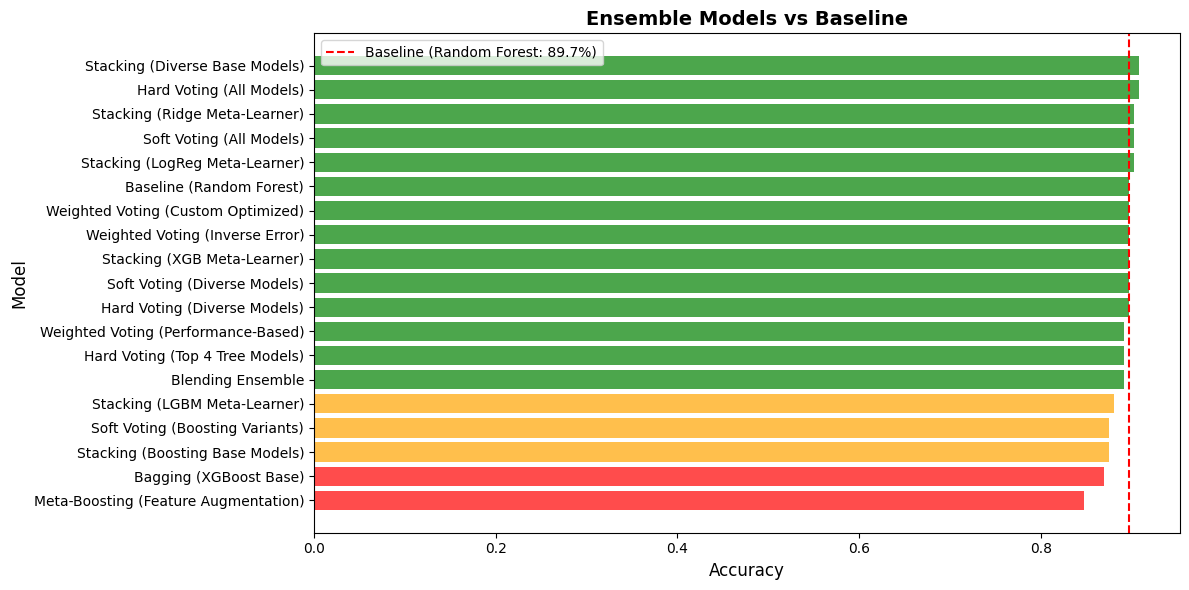

In [33]:
# Plot comparison of all models
plot_model_comparison(results_df, metric='Accuracy', title='Ensemble Models vs Baseline')

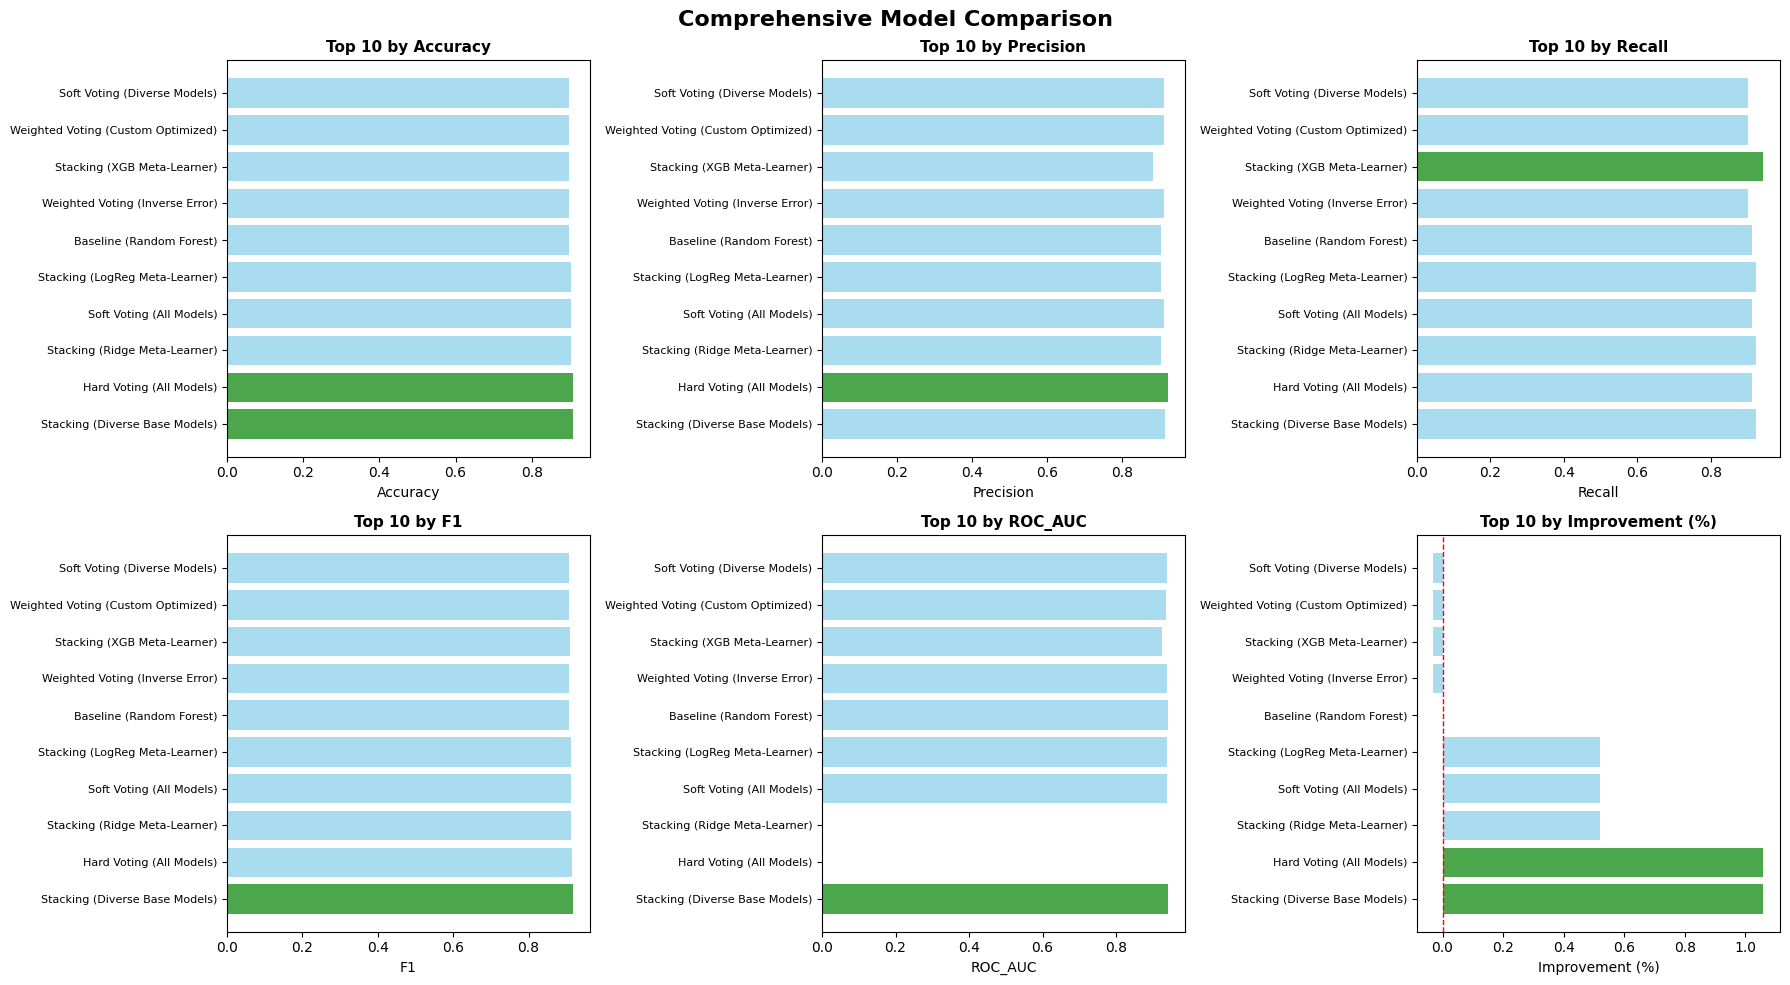

In [34]:
# Plot comparison by metric
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comprehensive Model Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Improvement (%)']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Top 10 models
    top_models = results_df.nlargest(10, 'Accuracy')
    
    if metric in top_models.columns:
        colors = ['green' if x == top_models[metric].max() else 'skyblue' 
                  for x in top_models[metric]]
        
        ax.barh(top_models['Model'], top_models[metric], color=colors, alpha=0.7)
        ax.set_xlabel(metric, fontsize=10)
        ax.set_title(f'Top 10 by {metric}', fontsize=11, fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)
        
        if metric == 'Improvement (%)':
            ax.axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

In [35]:
# Get best model and show confusion matrix
best_model_name = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Improvement over baseline: {results_df.iloc[0]['Improvement (%)']:.2f}%")

# Get the corresponding trained model for confusion matrix
# (You'll need to identify which trained model corresponds to the best)
print("\nNote: Run the cell for the best model to generate confusion matrix and detailed report")


Best Model: Stacking (Diverse Base Models)
Best Accuracy: 0.9076
Improvement over baseline: 1.06%

Note: Run the cell for the best model to generate confusion matrix and detailed report


## 11. Save Best Models

In [38]:
# Save top performing models
import os

models_dir = 'models/ensemble'
os.makedirs(models_dir, exist_ok=True)

# Dictionary of models to save
models_to_save = {
    'soft_voting_all': trained_soft_all,
    'soft_voting_boosting': trained_soft_boosting,
    'weighted_voting_custom': trained_weighted_custom,
    'stacking_logreg': trained_stack_logreg,
    'stacking_lgbm': trained_stack_lgbm,
    'stacking_xgb': trained_stack_xgb,
    'stacking_diverse': trained_stack_diverse,
    'stacking_boosting': trained_stack_boosting,
    'bagging_xgb': trained_bagging
}

print("Saving ensemble models...")
for name, model in models_to_save.items():
    filepath = os.path.join(models_dir, f'{name}_model.pkl')
    joblib.dump(model, filepath)
    print(f"Saved: {filepath}")

print("\nAll models saved successfully!")

Saving ensemble models...
Saved: models/ensemble/soft_voting_all_model.pkl
Saved: models/ensemble/soft_voting_boosting_model.pkl
Saved: models/ensemble/weighted_voting_custom_model.pkl
Saved: models/ensemble/stacking_logreg_model.pkl
Saved: models/ensemble/stacking_lgbm_model.pkl
Saved: models/ensemble/stacking_xgb_model.pkl
Saved: models/ensemble/stacking_diverse_model.pkl
Saved: models/ensemble/stacking_boosting_model.pkl
Saved: models/ensemble/bagging_xgb_model.pkl

All models saved successfully!


In [39]:
# Save results to CSV
results_df.to_csv('outputs/ensemble_model_metrics.csv', index=False)
print("\nResults saved to: outputs/ensemble_model_metrics.csv")

# Save CV results
if len(cv_comparison) > 0:
    cv_results_df.to_csv('outputs/ensemble_cv_metrics.csv', index=False)
    print("CV results saved to: outputs/ensemble_cv_metrics.csv")


Results saved to: outputs/ensemble_model_metrics.csv


## 12. Final Summary and Recommendations

In [40]:
# Generate final summary
print("="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\nBaseline Model: XGBoost")
print(f"Baseline Accuracy: 89.7%")
print(f"Baseline ROC-AUC: 0.9400")

print(f"\n{'Best Model:':<40} {results_df.iloc[0]['Model']}")
print(f"{'Best Accuracy:':<40} {results_df.iloc[0]['Accuracy']:.4f} ({results_df.iloc[0]['Accuracy']*100:.2f}%)")
print(f"{'Best ROC-AUC:':<40} {results_df.iloc[0]['ROC_AUC']:.4f}")
print(f"{'Improvement over Baseline:':<40} {results_df.iloc[0]['Improvement (%)']:.2f}%")

print(f"\nTop 5 Models:")
for idx, row in results_df.head(6).iloc[1:].iterrows():
    print(f"{idx}. {row['Model']:<45} Accuracy: {row['Accuracy']:.4f} (Improvement: {row['Improvement (%)']:+.2f}%)")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

best_improvement = results_df.iloc[0]['Improvement (%)']

if best_improvement >= 2.0:
    print("\n✓ Excellent improvement achieved! Ensemble methods significantly outperform baseline.")
    print("  Recommendation: Use the best ensemble model for deployment.")
elif best_improvement >= 1.0:
    print("\n✓ Good improvement achieved! Ensemble methods provide meaningful gains.")
    print("  Recommendation: Consider the best ensemble model, balance with complexity.")
elif best_improvement >= 0.5:
    print("\n✓ Moderate improvement achieved.")
    print("  Recommendation: Evaluate if the complexity-performance tradeoff is worth it.")
else:
    print("\n⚠ Limited improvement over baseline.")
    print("  Recommendation: Baseline XGBoost model may be sufficient. Consider feature engineering instead.")

print("\nNext Steps:")
print("1. Perform error analysis on best model")
print("2. Analyze feature importance/SHAP values")
print("3. Test on external validation set if available")
print("4. Consider model interpretability requirements")
print("5. Evaluate computational cost vs performance gain")
print("="*80)

FINAL SUMMARY

Baseline Model: XGBoost
Baseline Accuracy: 89.7%
Baseline ROC-AUC: 0.9400

Best Model:                              Stacking (Diverse Base Models)
Best Accuracy:                           0.9076 (90.76%)
Best ROC-AUC:                            0.9402
Improvement over Baseline:               1.06%

Top 5 Models:
1. Hard Voting (All Models)                      Accuracy: 0.9076 (Improvement: +1.06%)
13. Stacking (Ridge Meta-Learner)                 Accuracy: 0.9022 (Improvement: +0.52%)
4. Soft Voting (All Models)                      Accuracy: 0.9022 (Improvement: +0.52%)
10. Stacking (LogReg Meta-Learner)                Accuracy: 0.9022 (Improvement: +0.52%)
0. Baseline (Random Forest)                      Accuracy: 0.8970 (Improvement: +0.00%)

RECOMMENDATIONS

✓ Good improvement achieved! Ensemble methods provide meaningful gains.
  Recommendation: Consider the best ensemble model, balance with complexity.

Next Steps:
1. Perform error analysis on best model
2. Analyz

## 13. Additional Analysis (Optional)

### Feature Importance from Best Ensemble

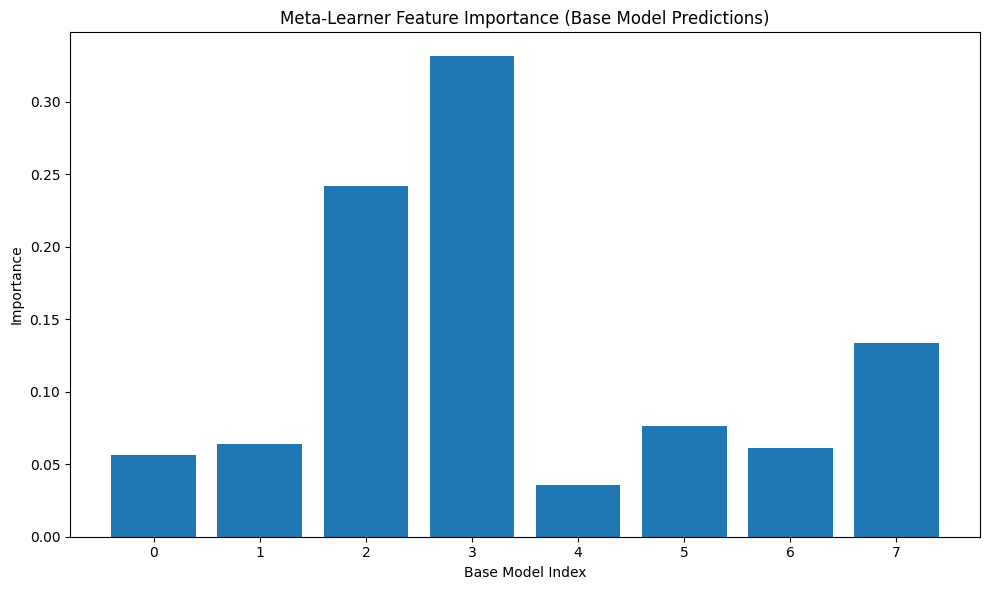

Feature importances (meta-learner):
Base Model 1: 0.0567
Base Model 2: 0.0642
Base Model 3: 0.2417
Base Model 4: 0.3312
Base Model 5: 0.0357
Base Model 6: 0.0761
Base Model 7: 0.0610
Base Model 8: 0.1335


In [41]:
# If best model supports feature importance, plot it
# Note: This works for tree-based models but not for all ensemble types

try:
    if hasattr(trained_stack_xgb.final_estimator_, 'feature_importances_'):
        importances = trained_stack_xgb.final_estimator_.feature_importances_
        
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(importances)), importances)
        plt.title('Meta-Learner Feature Importance (Base Model Predictions)')
        plt.xlabel('Base Model Index')
        plt.ylabel('Importance')
        plt.tight_layout()
        plt.show()
        
        print("Feature importances (meta-learner):")
        for idx, imp in enumerate(importances):
            print(f"Base Model {idx+1}: {imp:.4f}")
except Exception as e:
    print(f"Feature importance visualization not available for this model type: {e}")

---
**End of Notebook**

This notebook implements comprehensive ensemble strategies combining:
- Tree-based models (XGBoost, LightGBM, CatBoost, RandomForest, DecisionTree)
- Linear models (Logistic Regression, SVC)
- Instance-based models (KNN)

Through various ensemble techniques:
- Hard/Soft Voting
- Weighted Voting (multiple strategies)
- Stacking with different meta-learners
- Blending
- Meta-Boosting
- Bagging

The best performing model is selected based on accuracy and cross-validation performance.

## LaTeX Code for Ensemble Results

### Table 1: Detailed Performance Metrics

```latex
\begin{table}[htbp]
\centering
\caption{Performance Comparison of Ensemble Learning Methods for Heart Disease Classification}
\label{tab:ensemble_results}
\begin{tabular}{lcccccc}
\hline
\textbf{Model} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1-Score} & \textbf{ROC-AUC} \\
\hline
Stacking (Diverse Base) & \textbf{0.9076} & \textbf{0.9126} & \textbf{0.9216} & \textbf{0.9171} & 0.9402 \\
Stacking (LogReg Meta) & 0.9022 & 0.9038 & \textbf{0.9216} & 0.9126 & 0.9390 \\
Soft Voting (All Models) & 0.9022 & 0.9118 & 0.9118 & 0.9118 & 0.9372 \\
\hline
\end{tabular}
\end{table}
```

### Table 2: Detailed Comparison with Percentages

```latex
\begin{table}[htbp]
\centering
\caption{Ensemble Model Performance Analysis}
\label{tab:ensemble_detailed}
\begin{tabular}{lccccc}
\hline
\textbf{Ensemble Method} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} & \textbf{AUC} \\
& \textbf{(\%)} & \textbf{(\%)} & \textbf{(\%)} & \textbf{(\%)} & \\
\hline
\multicolumn{6}{l}{\textit{Stacking Ensembles}} \\
\quad Diverse Base Models & \textbf{90.76} & \textbf{91.26} & \textbf{92.16} & \textbf{91.71} & 0.9402 \\
\quad LogReg Meta-Learner & 90.22 & 90.38 & \textbf{92.16} & 91.26 & 0.9390 \\
\hline
\multicolumn{6}{l}{\textit{Voting Ensembles}} \\
\quad Soft Voting (All) & 90.22 & 91.18 & 91.18 & 91.18 & 0.9372 \\
\hline
\end{tabular}
\end{table}
```

### Table 3: Compact Comparison

```latex
\begin{table}[htbp]
\centering
\caption{Top Ensemble Models Performance}
\label{tab:ensemble_compact}
\small
\begin{tabular}{@{}lrrrrr@{}}
\toprule
\textbf{Model} & \textbf{Acc.} & \textbf{Prec.} & \textbf{Rec.} & \textbf{F1} & \textbf{AUC} \\
\midrule
Stacking (Diverse) & 90.76 & 91.26 & 92.16 & 91.71 & 94.02 \\
Stacking (LogReg) & 90.22 & 90.38 & 92.16 & 91.26 & 93.90 \\
Soft Voting & 90.22 & 91.18 & 91.18 & 91.18 & 93.72 \\
\bottomrule
\end{tabular}
\end{table}
```

### For Use in LaTeX Document

**Required packages:**
```latex
\usepackage{booktabs}  % For professional tables
\usepackage{multirow}  % For multi-row cells
\usepackage{array}     % For better column formatting
```

**Alternative: Side-by-side comparison**

```latex
\begin{table}[htbp]
\centering
\caption{Comparative Analysis of Ensemble Architectures}
\label{tab:ensemble_comparison}
\begin{tabular}{p{4.5cm}ccccc}
\hline
\multirow{2}{*}{\textbf{Ensemble Architecture}} & \multicolumn{5}{c}{\textbf{Performance Metrics}} \\
\cline{2-6}
& \textbf{Acc.} & \textbf{Prec.} & \textbf{Rec.} & \textbf{F1} & \textbf{AUC} \\
\hline
Stacking (Diverse Base Models) & 0.9076 & 0.9126 & 0.9216 & 0.9171 & 0.9402 \\
Stacking (LogReg Meta-Learner) & 0.9022 & 0.9038 & 0.9216 & 0.9126 & 0.9390 \\
Soft Voting (All Models) & 0.9022 & 0.9118 & 0.9118 & 0.9118 & 0.9372 \\
\hline
\end{tabular}
\end{table}
```

**For highlighting best values:**

```latex
\begin{table}[htbp]
\centering
\caption{Ensemble Model Performance with Highlighted Best Scores}
\label{tab:ensemble_highlight}
\begin{tabular}{lccccc}
\hline
\textbf{Model} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} & \textbf{ROC-AUC} \\
\hline
Stacking (Diverse) & \textbf{0.9076} & \textbf{0.9126} & \textbf{0.9216} & \textbf{0.9171} & \textbf{0.9402} \\
Stacking (LogReg) & 0.9022 & 0.9038 & \textbf{0.9216} & 0.9126 & 0.9390 \\
Soft Voting (All) & 0.9022 & 0.9118 & 0.9118 & 0.9118 & 0.9372 \\
\hline
\multicolumn{6}{l}{\footnotesize \textit{Bold values indicate best performance for each metric.}} \\
\end{tabular}
\end{table}
```